In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Uso de dispositivo: {device}")
import numpy as np
import pandas as pd
import seaborn as sn  # for heatmaps
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
%matplotlib inline
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


Uso de dispositivo: cuda


In [5]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Definir las transformaciones para tus imágenes de 200x200
# (Es una buena práctica normalizarlas y asegurarte de que todas midan lo mismo)
transformaciones = transforms.Compose([
    transforms.Resize((200, 200)),          # Asegura que todas sean de 200x200
    transforms.ToTensor(),                  # Convierte la imagen a Tensor de PyTorch (C x H x W)
    transforms.Normalize(                   # Normaliza los píxeles (ayuda a la red a entrenar mejor)
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

# 2. Ruta principal donde están las carpetas de las señas
ruta_dataset = "/home/fred/asl/asl_alphabet_train"
# 3. ¡LA MAGIA!: ImageFolder detecta automáticamente las carpetas como clases
dataset_completo = datasets.ImageFolder(root=ruta_dataset, transform=transformaciones)

# Curiosidad: Si quieres ver cómo mapeó las carpetas a números (ej: {'A': 0, 'B': 1...})
print("Clases detectadas:", dataset_completo.class_to_idx)
print("Total de imágenes:", len(dataset_completo))

# 4. Dividir el dataset: 80% para entrenar y 20% para validar el modelo
X_train = int(0.8 * len(dataset_completo))
y_train = len(dataset_completo) - X_train

train_dataset, val_dataset = random_split(dataset_completo, [X_train, y_train])

# 5. Crear los DataLaoders (los encargados de darle las imágenes en "paquetes" o batches a la ResNet)
BATCH_SIZE = 32  # Procesa de 32 en 32 imágenes para no saturar la memoria

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)




Clases detectadas: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'DEL': 4, 'E': 5, 'F': 6, 'G': 7, 'H': 8, 'I': 9, 'J': 10, 'K': 11, 'L': 12, 'M': 13, 'N': 14, 'NOTHING': 15, 'O': 16, 'P': 17, 'Q': 18, 'R': 19, 'S': 20, 'SPACE': 21, 'T': 22, 'U': 23, 'V': 24, 'W': 25, 'X': 26, 'Y': 27, 'Z': 28}
Total de imágenes: 87000


In [7]:
# Verificar
print(f"Train: {len(train_dataset)} imágenes")
print(f"Test:  {len(val_dataset)} imágenes")

Train: 69600 imágenes
Test:  17400 imágenes


In [8]:
# luego definir el modelo
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn
import torchvision.models as models

# 1. Descargamos una ResNet-18 preentrenada
# (Ya está diseñada perfectamente para imágenes grandes)
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 2. Vemos cuántas entradas tenía su última capa lineal original
num_ftrs = model.fc.in_features  # En ResNet-18 suele ser 512

# 3. Reemplazamos SU última capa por una que se adapte a TU problema
# Suponiendo que tu dataset tiene, por ejemplo, 10 o 24 clases
mis_clases_de_salida = 29
model.fc = nn.Linear(num_ftrs, mis_clases_de_salida)

# ¡Listo! Ya tienes una arquitectura de nivel profesional adaptada a tus imágenes

In [9]:
# parametro de perdida 
criterion= nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [14]:
nombres_clases=dataset_completo.classes
nombres_clases

['A',
 'B',
 'C',
 'D',
 'DEL',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'NOTHING',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'SPACE',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z']

In [16]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- ASEGURATE DE QUE EL MODELO ESTÉ EN EL DEVICE ---
model = model.to(device) 

start_time = time.time()

epochs = 3
train_losses = []
test_losses = []
train_correct = []
test_correct = []

total_train_imgs = len(train_loader.dataset)
total_test_imgs = len(val_loader.dataset)#val_loader

for i in range(epochs):
    trn_corr = 0
    tst_corr = 0
    running_train_loss = 0.0
    running_test_loss = 0.0
    
    # Listas para almacenar las predicciones de la ÚLTIMA época
    todas_las_etiquetas = []
    todas_las_predicciones = []
    
    # --- FASE DE ENTRENAMIENTO ---
    model.train() 
    
    for b, (X_train, y_train) in enumerate(train_loader):
        b += 1

        # Mover datos al dispositivo (CPU o GPU)
        X_train = X_train.to(device)
        y_train = y_train.to(device)
        
        # Apply the model
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
 
        # Tally the number of correct predictions
        predicted = torch.max(y_pred.data, 1)[1]
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr
        running_train_loss += loss.item() 
        
        # Update parameters
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Print interim results
        if b % 50 == 0:
            imagenes_procesadas = b * train_loader.batch_size
            accuracy_actual = trn_corr.item() * 100 / imagenes_procesadas
            print(f'epoch: {i+1:2}  batch: {b:4} [{imagenes_procesadas:6}/{total_train_imgs}]  '
                  f'loss: {loss.item():10.8f}  accuracy: {accuracy_actual:7.3f}%')
        
    train_losses.append(running_train_loss / len(train_loader))
    train_correct.append(trn_corr)
        
    # --- FASE DE TEST / EVALUACIÓN ---
    model.eval() 
    
    with torch.no_grad(): 
        for b_test, (X_test, y_test) in enumerate(val_loader):
            # Mover datos al dispositivo
            X_test = X_test.to(device)
            # Nota: Si usas la clase personalizada de test con strings, y_test no irá al device,
            # pero asumimos que aquí ya tienes las etiquetas mapeadas numéricamente.
            y_test_dev = y_test.to(device) 
            
            # Apply the model
            y_val = model(X_test)
            
            # Calculamos el loss de CADA batch
            loss_v = criterion(y_val, y_test_dev)
            running_test_loss += loss_v.item()

            # Tally the number of correct predictions
            predicted = torch.max(y_val.data, 1)[1] 
            tst_corr += (predicted == y_test_dev).sum()
            
            # Solo guardamos los datos para la matriz en la ÚLTIMA época
            if i == epochs - 1:
                todas_las_etiquetas.extend(y_test.cpu().numpy())
                todas_las_predicciones.extend(predicted.cpu().numpy())
            
    # Guardamos los resultados finales de test de esta época
    test_losses.append(running_test_loss / len(val_loader))
    test_correct.append(tst_corr)
    
    # Imprimir resumen de fin de época
    print(f'--- FIN ÉPOCA {i+1} ---')
    print(f'Train Accuracy: {trn_corr.item()*100/total_train_imgs:.2f}% | Test Accuracy: {tst_corr.item()*100/total_test_imgs:.2f}%\n')
        
print(f'\nDuration: {time.time() - start_time:.0f} seconds')


# =====================================================================
# --- CÁLCULO Y GRAFICADO DE LA MATRIZ DE CONFUSIÓN ---
# =====================================================================

# 1. Generar la matriz matemática usando scikit-learn
cm = confusion_matrix(todas_las_etiquetas, todas_las_predicciones)

q

epoch:  1  batch:   50 [  1600/69600]  loss: 0.00105222  accuracy:  98.812%
epoch:  1  batch:  100 [  3200/69600]  loss: 0.00022177  accuracy:  99.250%
epoch:  1  batch:  150 [  4800/69600]  loss: 0.00065441  accuracy:  99.250%
epoch:  1  batch:  200 [  6400/69600]  loss: 0.00336916  accuracy:  99.125%
epoch:  1  batch:  250 [  8000/69600]  loss: 0.00081615  accuracy:  99.237%
epoch:  1  batch:  300 [  9600/69600]  loss: 0.00015164  accuracy:  99.344%
epoch:  1  batch:  350 [ 11200/69600]  loss: 0.00003873  accuracy:  99.438%
epoch:  1  batch:  400 [ 12800/69600]  loss: 0.00063446  accuracy:  99.508%
epoch:  1  batch:  450 [ 14400/69600]  loss: 0.00028796  accuracy:  99.562%
epoch:  1  batch:  500 [ 16000/69600]  loss: 0.00002198  accuracy:  99.606%
epoch:  1  batch:  550 [ 17600/69600]  loss: 0.00004075  accuracy:  99.642%
epoch:  1  batch:  600 [ 19200/69600]  loss: 0.00003189  accuracy:  99.672%
epoch:  1  batch:  650 [ 20800/69600]  loss: 0.00007966  accuracy:  99.697%
epoch:  1  b

AttributeError: 'Subset' object has no attribute 'classes'

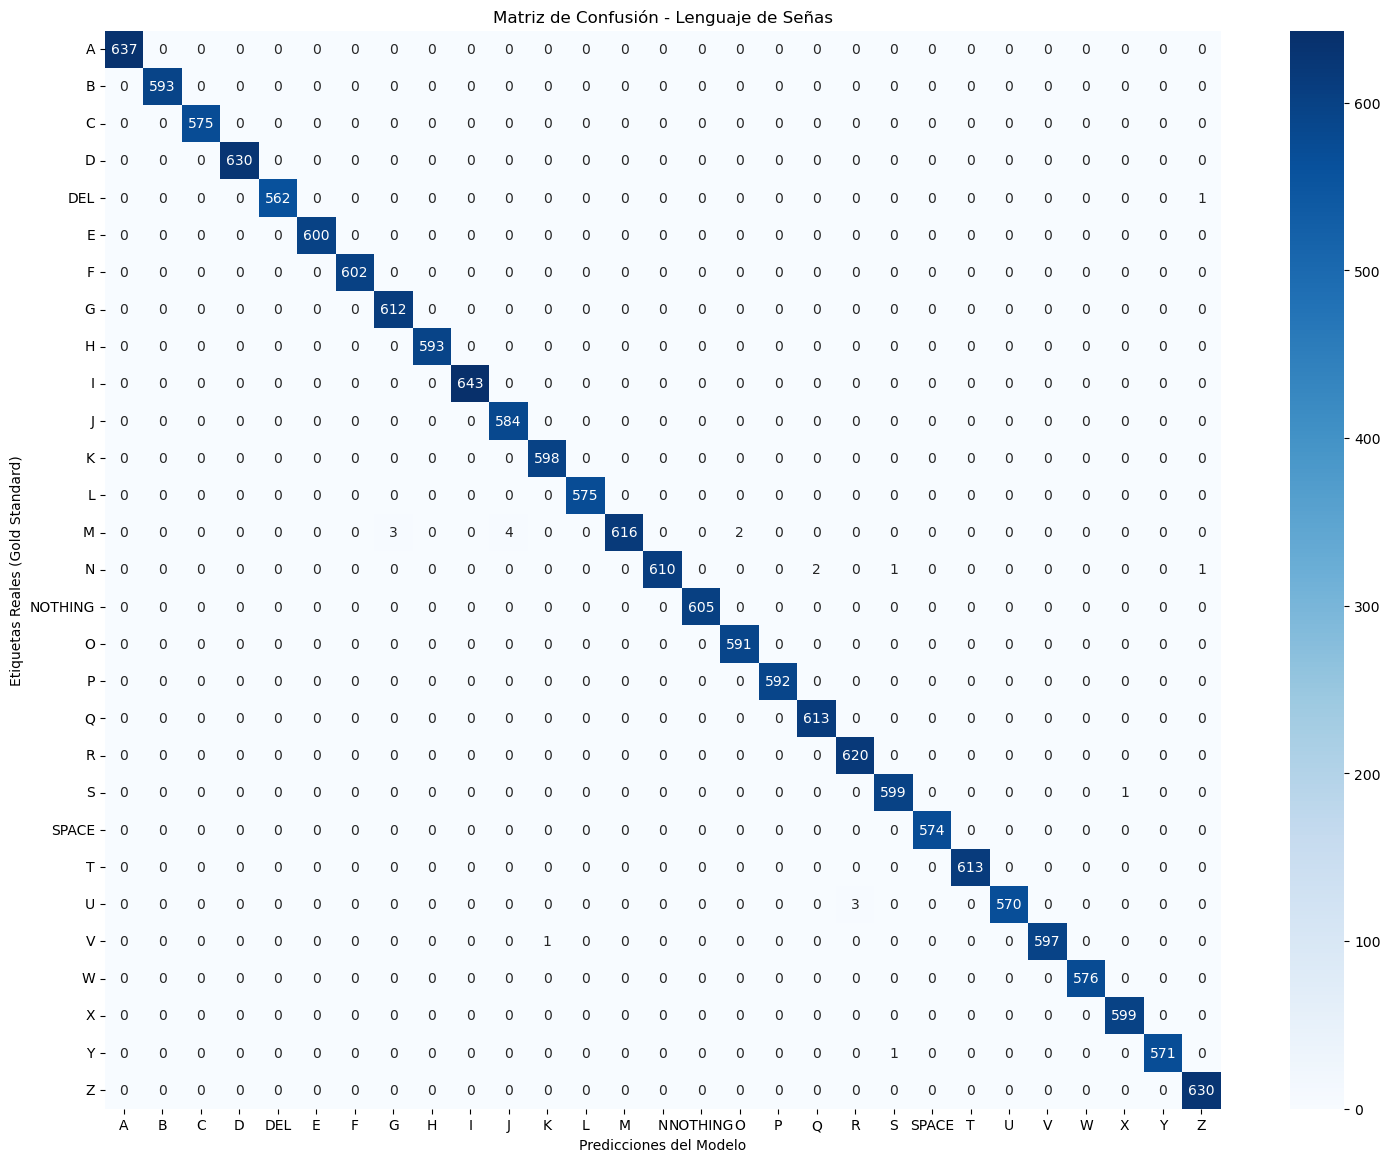


--- Reporte de Clasificación Detallado ---
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       637
           B       1.00      1.00      1.00       593
           C       1.00      1.00      1.00       575
           D       1.00      1.00      1.00       630
         DEL       1.00      1.00      1.00       563
           E       1.00      1.00      1.00       600
           F       1.00      1.00      1.00       602
           G       1.00      1.00      1.00       612
           H       1.00      1.00      1.00       593
           I       1.00      1.00      1.00       643
           J       0.99      1.00      1.00       584
           K       1.00      1.00      1.00       598
           L       1.00      1.00      1.00       575
           M       1.00      0.99      0.99       625
           N       1.00      0.99      1.00       614
     NOTHING       1.00      1.00      1.00       605
           O       1.00      1.00    

In [17]:

# 2. Conseguir los nombres de las clases (en orden) desde tu train_dataset
# Si no lo tienes a mano, puedes usar list(range(29))
nombres_clases=dataset_completo.classes if 'train_dataset' in locals() else [str(n) for n in range(29)]

# 3. Graficarla usando Seaborn para que sea legible (ya que son 29 clases)
plt.figure(figsize=(18, 14)) # Un tamaño grande para que quepan las 29 clases sin amontonarse
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nombres_clases, yticklabels=nombres_clases)

plt.xlabel('Predicciones del Modelo')
plt.ylabel('Etiquetas Reales (Gold Standard)')
plt.title('Matriz de Confusión - Lenguaje de Señas')
plt.show()

# 4. Imprimir un reporte detallado en texto (Precision, Recall, F1-Score por clase)
print("\n--- Reporte de Clasificación Detallado ---")
print(classification_report(todas_las_etiquetas, todas_las_predicciones, target_names=nombres_clases))

In [20]:
import torch
import torchvision.models as models
import torch.nn as nn

# Paso 1: Reconstruir la arquitectura exactamente igual (ResNet18 con 29 clases)
model_nuevo = models.resnet18() # No necesitas poner weights aquí porque le vas a cargar los tuyos
num_ftrs = model_nuevo.fc.in_features
model_nuevo.fc = nn.Linear(num_ftrs, 29) # Reemplazamos la capa final para que coincida con tus 29 clases

# Paso 2: Cargar los pesos guardados en la estructura
ruta_guardado = "Traductor4.pth"
model_nuevo.load_state_dict(torch.load(ruta_guardado))

# Paso 3: ¡MUY IMPORTANTE! Poner el modelo en modo evaluación
model_nuevo.eval()

print("¡Modelo cargado y listo para usar en predicciones!")

¡Modelo cargado y listo para usar en predicciones!


/tmp/ipykernel_10667/711650666.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_nuevo.load_state_dict(torch.load(ruta_guardado))


In [19]:
torch.save(model.state_dict(),'Traductor4.pth')